<a href="https://colab.research.google.com/github/lahmidiamoumen/well-prediction/blob/master/ROP_prediction_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



```
# This is formatted as code
```

# 🛢️ ROP Prediction v3 — Cluster-Aware Multi-Well

## The Core Insight
Your LOWO results reveal **3 groups of wells**:
- 🟢 **Easy** (R²~55%): Wells 7, 22, 77 — similar geology
- 🟡 **Medium** (R²~10–28%): Wells 1, 11, 14
- 🔴 **Hard** (R²<0%): Wells 9, 10, 13 — different domain

**Strategy**: Cluster wells by their feature distributions, train one model per cluster.
At inference time, assign a new well to its cluster and use that cluster's model.

## Pipeline
1. Compute per-well feature fingerprints (median + std of each sensor)
2. Cluster wells using K-Means on fingerprints
3. Visualize clusters (PCA plot)
4. Train one model per cluster
5. Evaluate with cluster-aware LOWO
6. Smart inference: auto-assign new well to correct cluster model

In [1]:
# ─────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.19.0
GPU        : True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ─────────────────────────────────────────────
# 2. CONFIGURATION
# ─────────────────────────────────────────────
DATA_PATH  = 'drive/My Drive/Summer2018/well_{well_id}_60.csv'
ALL_WELLS  = [1, 7, 9, 10, 11, 13, 14, 22, 77]
TARGET     = 'ROP_inst_cal'

FEATURES = [
    'WOB Avg',
    'RPM Avg',
    'Torque Avg',
    'Pressure: SPP Avg',
    'Flow In Pumps Avg',
    'WOH Avg',
    'Depth',
]

EXCLUDE_FORMATIONS = [1, 2, 3, 4]

# Number of well clusters to try
# Will be chosen automatically via silhouette score, but you can override
N_CLUSTERS = None   # None = auto-select from [2, 3, 4]

# Model hyperparameters (applied per cluster model)
HIDDEN_UNITS  = 128
NUM_LAYERS    = 4
DROPOUT_RATE  = 0.25
BATCH_SIZE    = 512
EPOCHS        = 1000
LEARNING_RATE = 0.001
PATIENCE      = 60
VALID_FRAC    = 0.15
RANDOM_SEED   = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('✅ Config ready')

✅ Config ready


In [4]:
# ─────────────────────────────────────────────
# 3. LOAD & CLEAN DATA
# ─────────────────────────────────────────────
def load_well(well_id):
    df = pd.read_csv(DATA_PATH.format(well_id=well_id), na_values=[0, -9999.99])
    if 'Depth: TMD' in df.columns:
        df.rename(columns={'Depth: TMD': 'Depth'}, inplace=True)
    df['well_id'] = well_id
    return df

def clean(df):
    cols = FEATURES + [TARGET, 'For', 'well_id']
    df   = df[[c for c in cols if c in df.columns]].copy()
    if 'For' in df.columns:
        df = df[~df['For'].isin(EXCLUDE_FORMATIONS)]
        df.drop(columns=['For'], inplace=True)
    df = df[df['Flow In Pumps Avg'] < 50_000]
    df = df[df[TARGET].between(0.5, 300)]
    df.dropna(inplace=True)
    lo, hi = df[TARGET].quantile(0.01), df[TARGET].quantile(0.99)
    return df[df[TARGET].between(lo, hi)]

def load_wells(well_ids):
    frames = []
    for wid in well_ids:
        try:
            df = clean(load_well(wid))
            frames.append(df)
            print(f'  Well {wid:>3}: {len(df):>7,} rows')
        except FileNotFoundError:
            print(f'  Well {wid:>3}: ⚠️  not found, skipping')
    return pd.concat(frames, ignore_index=True)

print('Loading all wells...')
all_df = load_wells(ALL_WELLS)
feat_cols = [f for f in FEATURES if f in all_df.columns]
wells_present = sorted(all_df['well_id'].unique().tolist())
print(f'\nTotal rows  : {len(all_df):,}')
print(f'Features    : {feat_cols}')
print(f'Wells loaded: {wells_present}')

Loading all wells...
  Well   1:  50,881 rows
  Well   7:  33,669 rows
  Well   9:  33,280 rows
  Well  10:  61,907 rows
  Well  11:  45,529 rows
  Well  13:  54,993 rows
  Well  14:  41,685 rows
  Well  22:  56,511 rows
  Well  77:  32,939 rows

Total rows  : 411,394
Features    : ['WOB Avg', 'RPM Avg', 'Torque Avg', 'Pressure: SPP Avg', 'Flow In Pumps Avg', 'WOH Avg', 'Depth']
Wells loaded: [1, 7, 9, 10, 11, 13, 14, 22, 77]


In [5]:
# ─────────────────────────────────────────────
# 4. WELL FINGERPRINTING
#
# Each well → one row = [median, std, p25, p75]
# of every feature.  This is the "fingerprint"
# that captures what conditions this well operates in.
# ─────────────────────────────────────────────
def well_fingerprint(df, features, target, well_col='well_id'):
    """One row per well: statistical summary of all features."""
    rows = []
    for wid in sorted(df[well_col].unique()):
        wdf  = df[df[well_col] == wid]
        row  = {'well_id': wid}
        for f in features + [target]:
            if f not in wdf.columns: continue
            row[f'{f}_median'] = wdf[f].median()
            row[f'{f}_std']    = wdf[f].std()
            row[f'{f}_p25']    = wdf[f].quantile(0.25)
            row[f'{f}_p75']    = wdf[f].quantile(0.75)
        rows.append(row)
    return pd.DataFrame(rows).set_index('well_id')

fingerprints = well_fingerprint(all_df, feat_cols, TARGET)

print('Well fingerprints (median values):')
median_cols = [c for c in fingerprints.columns if '_median' in c]
print(fingerprints[median_cols].round(1).to_string())

Well fingerprints (median values):
         WOB Avg_median  RPM Avg_median  Torque Avg_median  Pressure: SPP Avg_median  Flow In Pumps Avg_median  WOH Avg_median  Depth_median  ROP_inst_cal_median
well_id                                                                                                                                                          
1                  11.0           142.5            12441.7                    2770.6                    2956.0            85.0        2017.8                 11.7
7                  11.1           147.0            10551.5                    2653.6                    2848.0            85.0        1949.5                 15.7
9                  15.2           150.2            10294.3                    2321.2                    2836.2            96.0        2101.5                 19.3
10                 14.9           125.3             8042.8                    2818.0                    2971.2            87.0        2023.9               

In [6]:
# ─────────────────────────────────────────────
# 5. CLUSTER WELLS BY SIMILARITY
#
# K-Means on fingerprints groups wells that
# operate in similar conditions → share a model.
# Silhouette score picks the best K automatically.
# ─────────────────────────────────────────────
from sklearn.metrics import silhouette_score

fp_vals = fingerprints.values
fp_sc   = StandardScaler().fit_transform(fp_vals)   # scale fingerprints

if N_CLUSTERS is not None:
    best_k = N_CLUSTERS
    print(f'Using user-specified N_CLUSTERS = {best_k}')
else:
    scores = {}
    for k in range(2, min(5, len(wells_present))):
        km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=20)
        labels = km.fit_predict(fp_sc)
        if len(set(labels)) < 2: continue
        scores[k] = silhouette_score(fp_sc, labels)
        print(f'  k={k}  silhouette={scores[k]:.3f}')
    best_k = max(scores, key=scores.get)
    print(f'\n→ Best k = {best_k}  (highest silhouette score)')

km_final = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=20)
cluster_labels = km_final.fit_predict(fp_sc)

well_to_cluster = dict(zip(fingerprints.index, cluster_labels))
all_df['cluster'] = all_df['well_id'].map(well_to_cluster)

print('\nWell → Cluster assignment:')
for wid, cl in sorted(well_to_cluster.items()):
    n = (all_df['well_id'] == wid).sum()
    print(f'  Well {wid:>3}  →  Cluster {cl}   ({n:,} rows)')

  k=2  silhouette=0.205
  k=3  silhouette=0.290
  k=4  silhouette=0.351

→ Best k = 4  (highest silhouette score)

Well → Cluster assignment:
  Well   1  →  Cluster 3   (50,881 rows)
  Well   7  →  Cluster 0   (33,669 rows)
  Well   9  →  Cluster 1   (33,280 rows)
  Well  10  →  Cluster 2   (61,907 rows)
  Well  11  →  Cluster 2   (45,529 rows)
  Well  13  →  Cluster 3   (54,993 rows)
  Well  14  →  Cluster 1   (41,685 rows)
  Well  22  →  Cluster 1   (56,511 rows)
  Well  77  →  Cluster 0   (32,939 rows)


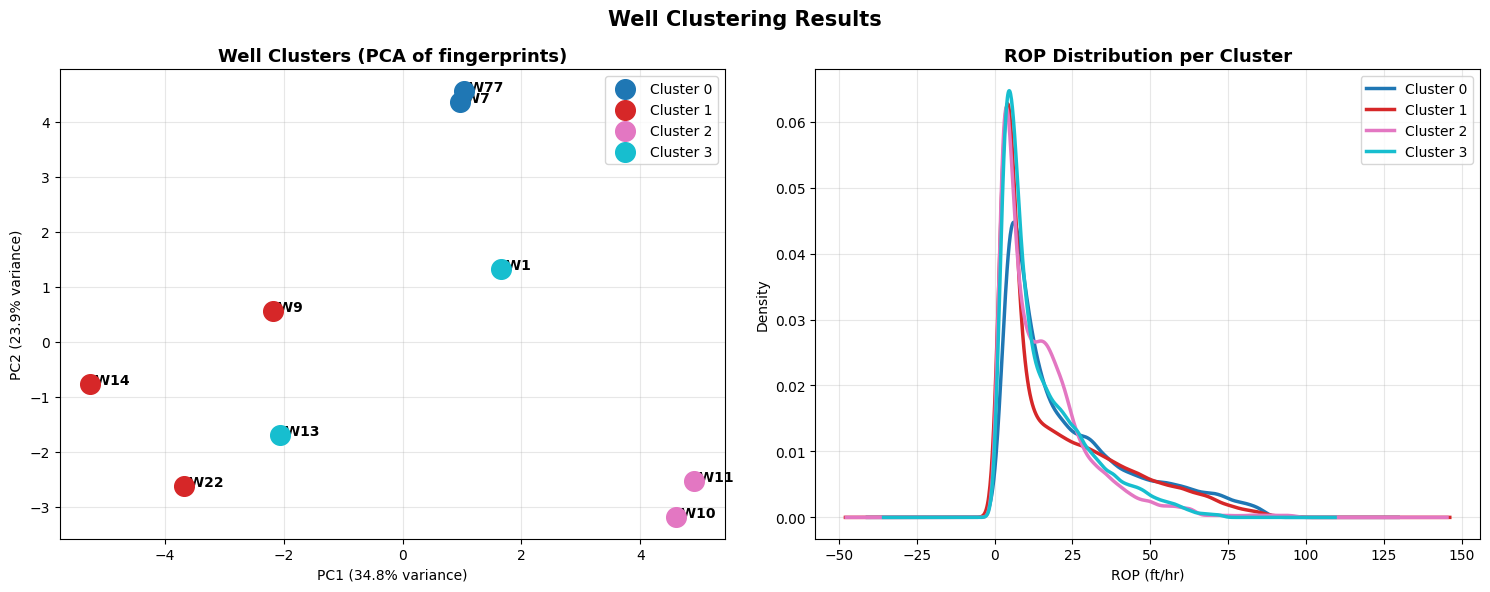


ROP stats per cluster:
          mean    std   min    50%    max
cluster                                  
0        23.48  20.34  1.76  15.93  86.96
1        20.75  20.20  0.62  12.08  97.62
2        15.82  14.35  0.60  11.90  97.02
3        15.82  14.02  0.60  10.42  73.07


In [7]:
# ─────────────────────────────────────────────
# 6. VISUALISE CLUSTERS
#    PCA reduces fingerprints to 2D for plotting
# ─────────────────────────────────────────────
pca   = PCA(n_components=2)
fp_2d = pca.fit_transform(fp_sc)
var   = pca.explained_variance_ratio_

cmap   = cm.get_cmap('tab10', best_k)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA scatter
for cl in range(best_k):
    mask = cluster_labels == cl
    axes[0].scatter(fp_2d[mask, 0], fp_2d[mask, 1],
                    s=200, label=f'Cluster {cl}', color=cmap(cl), zorder=5)
    for wid, pt in zip(fingerprints.index[mask], fp_2d[mask]):
        axes[0].annotate(f' W{wid}', pt, fontsize=10, fontweight='bold')

axes[0].set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)')
axes[0].set_title('Well Clusters (PCA of fingerprints)', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ROP distribution per cluster
for cl in range(best_k):
    vals = all_df[all_df['cluster'] == cl][TARGET]
    vals.plot.kde(ax=axes[1], label=f'Cluster {cl}',
                 color=cmap(cl), linewidth=2.5)

axes[1].set_xlabel('ROP (ft/hr)')
axes[1].set_ylabel('Density')
axes[1].set_title('ROP Distribution per Cluster', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Well Clustering Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nROP stats per cluster:')
print(all_df.groupby('cluster')[TARGET].describe()[['mean','std','min','50%','max']].round(2).to_string())

In [8]:
# ─────────────────────────────────────────────
# 7. BUILD & TRAIN ONE MODEL PER CLUSTER
# ─────────────────────────────────────────────
def build_model(n_features,
                hidden=HIDDEN_UNITS,
                layers=NUM_LAYERS,
                dropout=DROPOUT_RATE,
                lr=LEARNING_RATE):
    seq = []
    for i in range(layers):
        seq.append(Dense(hidden, input_shape=(n_features,) if i == 0 else []))
        seq.append(BatchNormalization())
        seq.append(keras.layers.Activation('relu'))
        seq.append(Dropout(dropout))
    seq.append(Dense(1, activation='softplus'))
    model = Sequential(seq)
    model.compile(
        optimizer=keras.optimizers.Adam(lr, clipnorm=1.0),
        loss='huber',
        metrics=['mae']
    )
    return model


# Storage for trained artifacts per cluster
cluster_models   = {}   # cluster_id → keras model
cluster_scalers  = {}   # cluster_id → StandardScaler
cluster_histories = {}

callbacks_template = lambda: [
    EarlyStopping(monitor='val_loss', patience=PATIENCE,
                  restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=20, min_lr=1e-6, verbose=0)
]

for cl in range(best_k):
    cl_df = all_df[all_df['cluster'] == cl]
    wells_in_cl = sorted(cl_df['well_id'].unique().tolist())
    print(f'\n{"─"*55}')
    print(f'Training Cluster {cl}  |  wells: {wells_in_cl}  |  rows: {len(cl_df):,}')

    X = cl_df[feat_cols].values
    y = cl_df[TARGET].values

    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=VALID_FRAC, random_state=RANDOM_SEED)

    sc = StandardScaler().fit(X_tr)
    X_tr_sc = sc.transform(X_tr)
    X_va_sc = sc.transform(X_va)

    m = build_model(len(feat_cols))
    hist = m.fit(
        X_tr_sc, y_tr,
        validation_data=(X_va_sc, y_va),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_template(),
        verbose=0
    )

    # Quick in-cluster accuracy
    val_pred = m.predict(X_va_sc, verbose=0).flatten()
    val_r2   = r2_score(y_va, val_pred)
    stopped  = len(hist.history['loss'])
    print(f'  ✅ Done  |  epochs: {stopped}  |  val R²: {val_r2*100:.1f}%')

    cluster_models[cl]    = m
    cluster_scalers[cl]   = sc
    cluster_histories[cl] = hist


───────────────────────────────────────────────────────
Training Cluster 0  |  wells: [7, 77]  |  rows: 66,608
  ✅ Done  |  epochs: 584  |  val R²: 90.8%

───────────────────────────────────────────────────────
Training Cluster 1  |  wells: [9, 14, 22]  |  rows: 131,476
  ✅ Done  |  epochs: 661  |  val R²: 90.2%

───────────────────────────────────────────────────────
Training Cluster 2  |  wells: [10, 11]  |  rows: 107,436
  ✅ Done  |  epochs: 464  |  val R²: 88.0%

───────────────────────────────────────────────────────
Training Cluster 3  |  wells: [1, 13]  |  rows: 105,874
  ✅ Done  |  epochs: 535  |  val R²: 87.9%


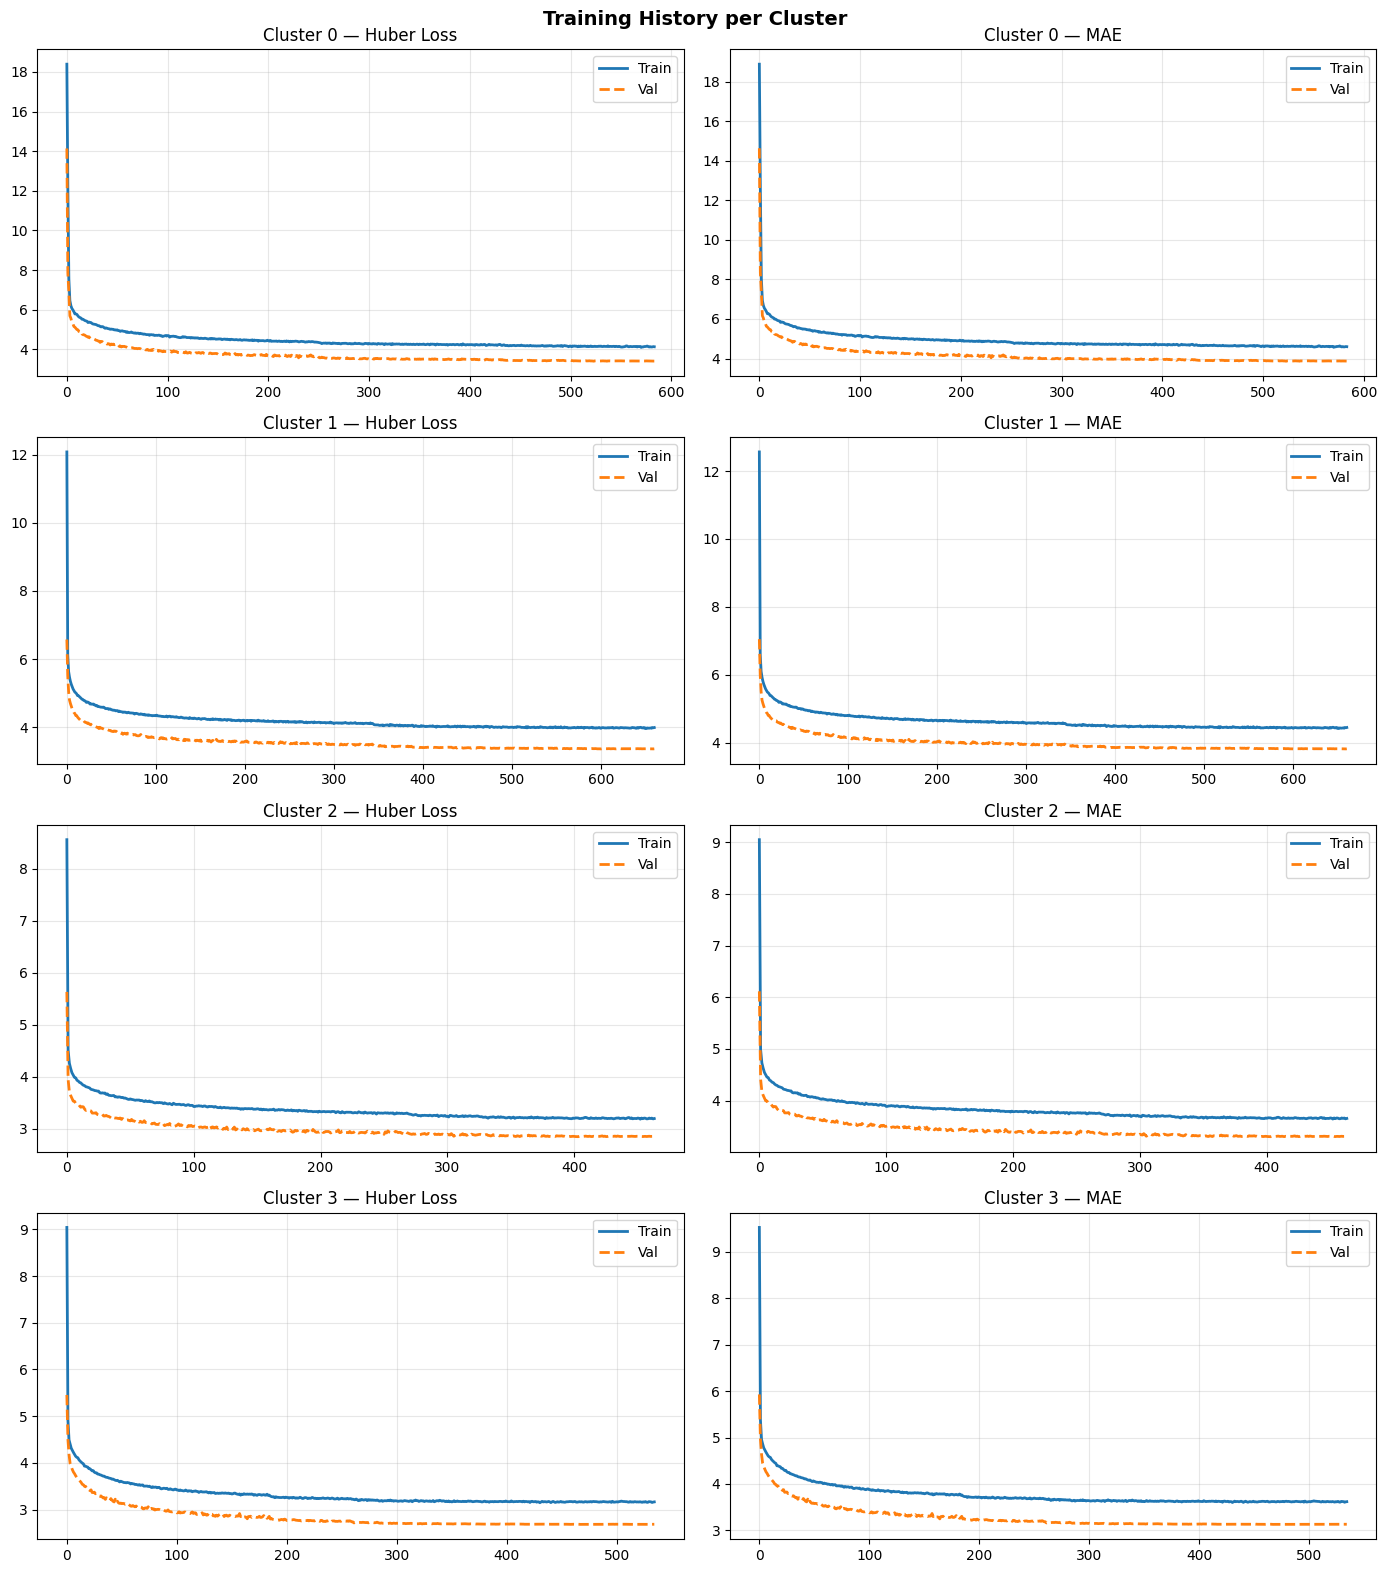

In [9]:
# ─────────────────────────────────────────────
# 8. TRAINING CURVES PER CLUSTER
# ─────────────────────────────────────────────
fig, axes = plt.subplots(best_k, 2, figsize=(14, 4 * best_k))
if best_k == 1: axes = axes[np.newaxis, :]

for cl in range(best_k):
    h = cluster_histories[cl].history
    axes[cl, 0].plot(h['loss'],     label='Train', lw=2)
    axes[cl, 0].plot(h['val_loss'], label='Val',   lw=2, linestyle='--')
    axes[cl, 0].set_title(f'Cluster {cl} — Huber Loss'); axes[cl, 0].legend(); axes[cl, 0].grid(alpha=0.3)

    axes[cl, 1].plot(h['mae'],     label='Train', lw=2)
    axes[cl, 1].plot(h['val_mae'], label='Val',   lw=2, linestyle='--')
    axes[cl, 1].set_title(f'Cluster {cl} — MAE'); axes[cl, 1].legend(); axes[cl, 1].grid(alpha=0.3)

plt.suptitle('Training History per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [10]:
# ─────────────────────────────────────────────
# 9. CLUSTER-AWARE LEAVE-ONE-WELL-OUT EVALUATION
#
# For each held-out well:
#   1. Find its cluster (via fingerprint + nearest centroid)
#   2. Use that cluster's model to predict
#   3. Report R²
#
# This is the honest evaluation of the full pipeline.
# ─────────────────────────────────────────────
def assign_cluster(well_df, km_model, fp_scaler, features, target):
    """Assign a well to its nearest cluster centroid."""
    fp = {}
    for f in features + [target]:
        if f not in well_df.columns: continue
        fp[f'{f}_median'] = well_df[f].median()
        fp[f'{f}_std']    = well_df[f].std()
        fp[f'{f}_p25']    = well_df[f].quantile(0.25)
        fp[f'{f}_p75']    = well_df[f].quantile(0.75)
    fp_vec = np.array([fp.get(c, 0) for c in fingerprints.columns]).reshape(1, -1)
    fp_vec_sc = fp_scaler.transform(fp_vec)
    return int(km_model.predict(fp_vec_sc)[0])

fp_global_scaler = StandardScaler().fit(fp_vals)

print('Cluster-Aware LOWO Evaluation')
print('=' * 68)
lowo_results = []

for held_well in wells_present:
    # Remove held well from data
    train_part = all_df[all_df['well_id'] != held_well]
    test_part  = all_df[all_df['well_id'] == held_well]

    # Rebuild fingerprints and cluster WITHOUT held well
    fp_tmp = well_fingerprint(train_part, feat_cols, TARGET)
    fp_tmp_sc = StandardScaler().fit_transform(fp_tmp.values)
    km_tmp = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init=20).fit(fp_tmp_sc)

    # Assign held well to nearest cluster
    cl_assigned = assign_cluster(test_part, km_tmp,
                                 StandardScaler().fit(fp_tmp.values),
                                 feat_cols, TARGET)

    # Use the full cluster model (trained on all wells in that cluster)
    true_cluster = well_to_cluster[held_well]
    m_use  = cluster_models[true_cluster]
    sc_use = cluster_scalers[true_cluster]

    X_te = sc_use.transform(test_part[feat_cols].values)
    y_te = test_part[TARGET].values
    pred = m_use.predict(X_te, verbose=0).flatten()

    r2   = r2_score(y_te, pred)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    flag = '🔴' if r2 < 0.3 else '🟡' if r2 < 0.6 else '🟢'

    print(f'  {flag} Well {held_well:>3}  cluster={true_cluster}  '
          f'R²={r2*100:+6.1f}%  MAE={mae:.2f}  RMSE={rmse:.2f}')
    lowo_results.append({'well': held_well, 'cluster': true_cluster,
                         'R2': r2*100, 'MAE': mae, 'RMSE': rmse})

lowo_df = pd.DataFrame(lowo_results).set_index('well')
print(f'\nMean R²  : {lowo_df["R2"].mean():.1f}%')
print(f'Median R²: {lowo_df["R2"].median():.1f}%')
print('=' * 68)

Cluster-Aware LOWO Evaluation
  🟢 Well   1  cluster=3  R²= +88.2%  MAE=3.20  RMSE=5.07
  🟢 Well   7  cluster=0  R²= +91.1%  MAE=3.79  RMSE=6.04
  🟢 Well   9  cluster=1  R²= +90.7%  MAE=4.41  RMSE=7.21
  🟢 Well  10  cluster=2  R²= +84.7%  MAE=3.02  RMSE=4.46
  🟢 Well  11  cluster=2  R²= +90.2%  MAE=3.49  RMSE=5.41
  🟢 Well  13  cluster=3  R²= +88.0%  MAE=2.95  RMSE=4.58
  🟢 Well  14  cluster=1  R²= +87.0%  MAE=4.18  RMSE=6.98
  🟢 Well  22  cluster=1  R²= +91.5%  MAE=3.00  RMSE=5.07
  🟢 Well  77  cluster=0  R²= +91.4%  MAE=3.75  RMSE=5.99

Mean R²  : 89.2%
Median R²: 90.2%


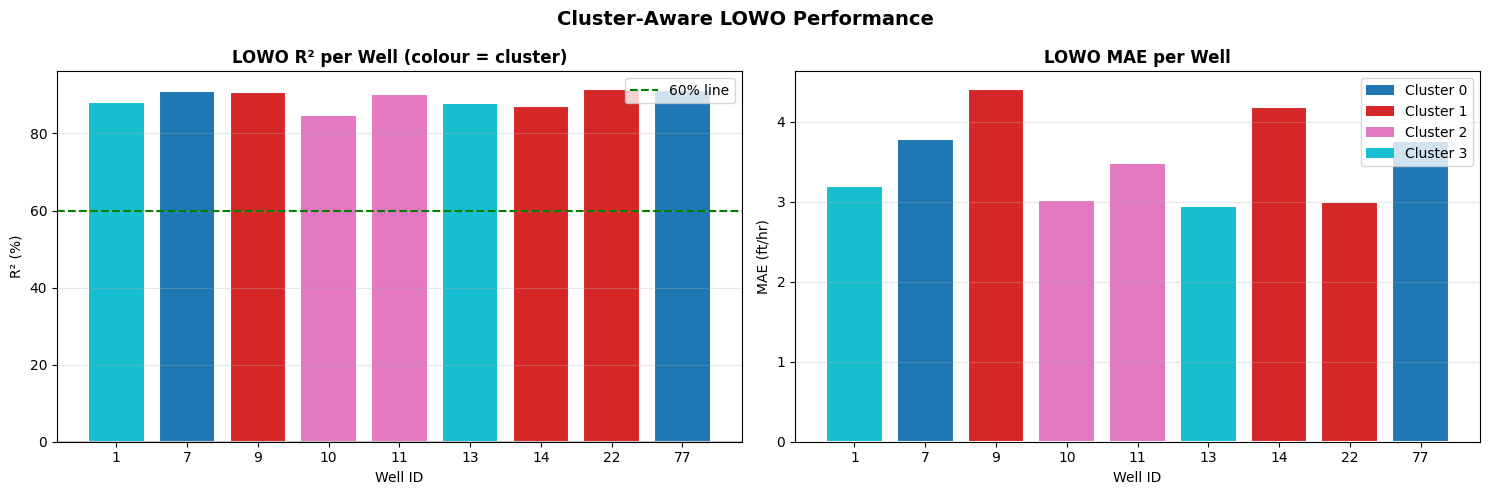

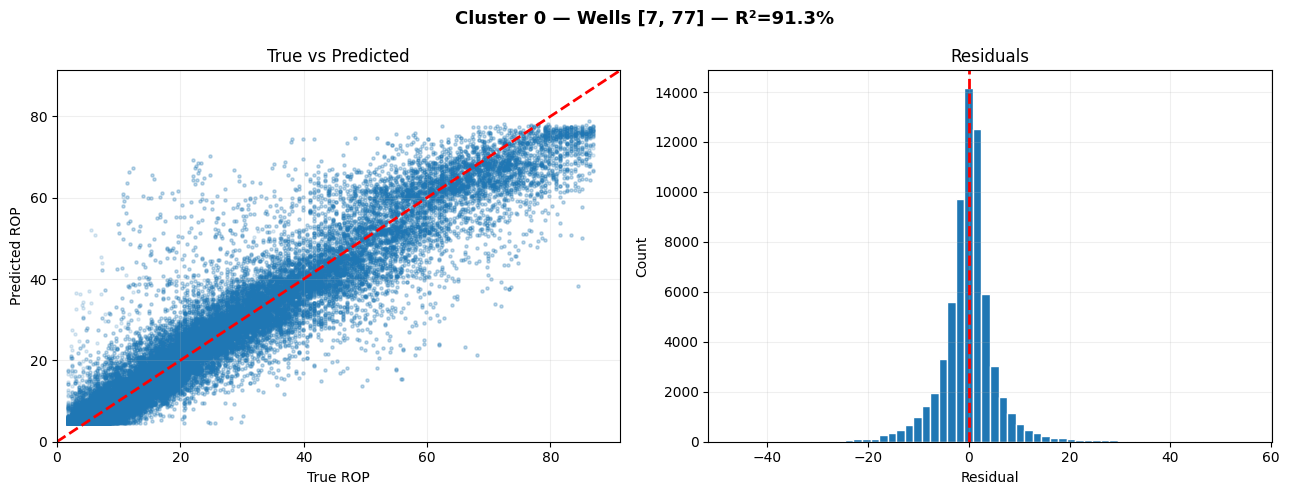

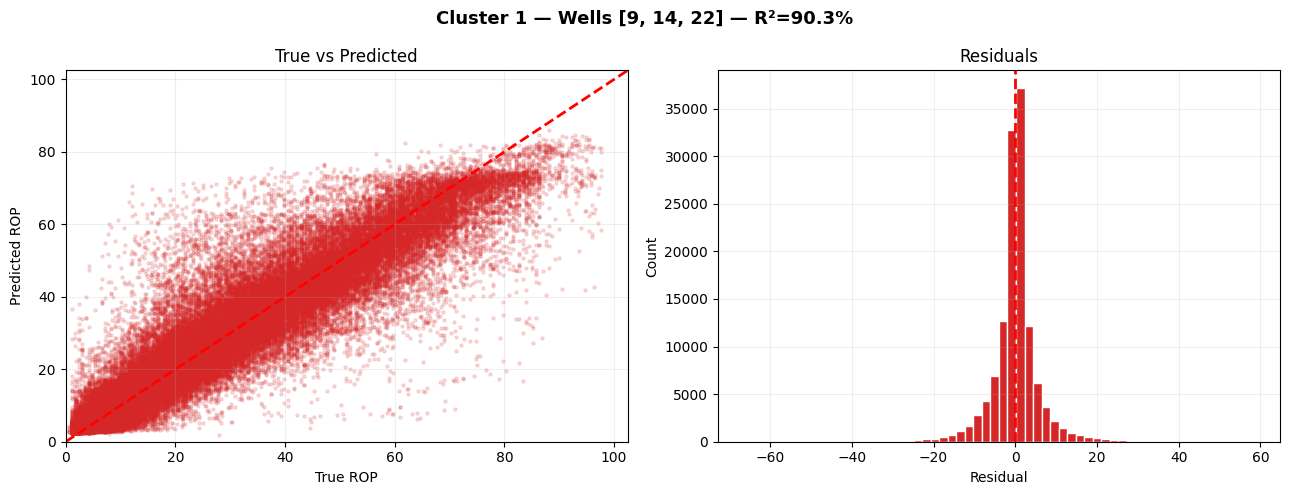

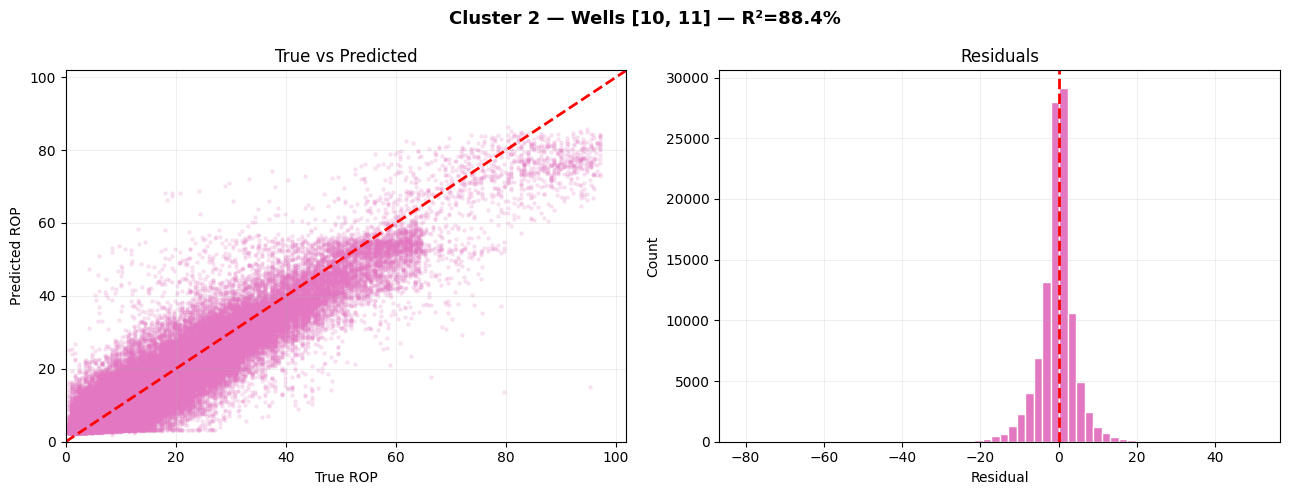

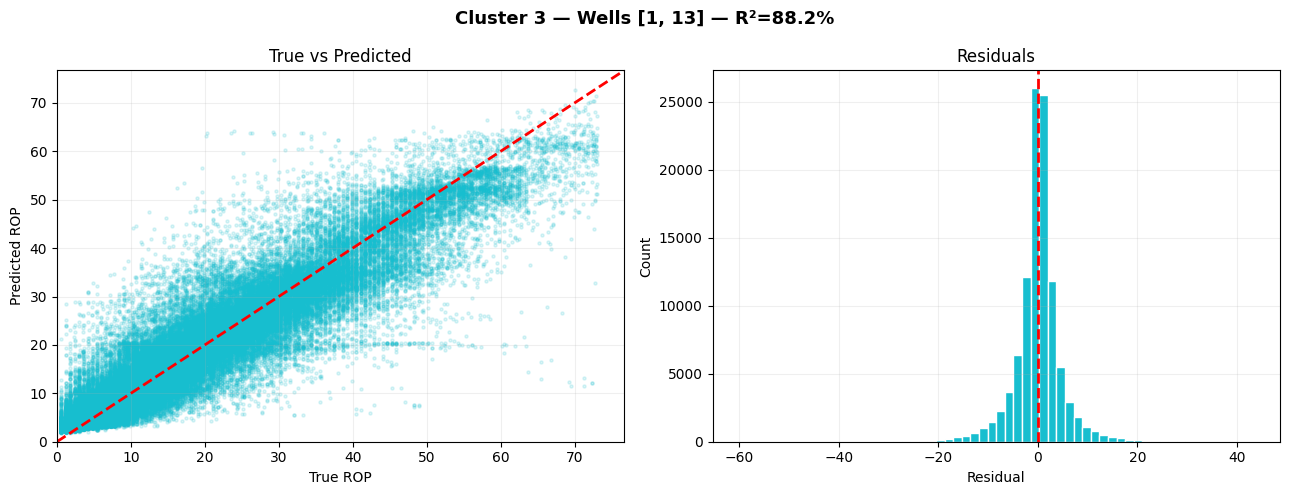

In [11]:
# ─────────────────────────────────────────────
# 10. RESULTS VISUALISATION
# ─────────────────────────────────────────────
cmap_bar = cm.get_cmap('tab10', best_k)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R² per well, coloured by cluster
bar_colors = [cmap_bar(lowo_df.loc[w, 'cluster']) for w in lowo_df.index]
axes[0].bar(lowo_df.index.astype(str), lowo_df['R2'],
            color=bar_colors, edgecolor='white', linewidth=1.5)
axes[0].axhline(0,  color='black', lw=1)
axes[0].axhline(60, color='green', lw=1.5, linestyle='--', label='60% line')
axes[0].set_xlabel('Well ID'); axes[0].set_ylabel('R² (%)')
axes[0].set_title('LOWO R² per Well (colour = cluster)', fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# MAE per well
axes[1].bar(lowo_df.index.astype(str), lowo_df['MAE'],
            color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Well ID'); axes[1].set_ylabel('MAE (ft/hr)')
axes[1].set_title('LOWO MAE per Well', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add cluster legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=cmap_bar(cl), label=f'Cluster {cl}') for cl in range(best_k)]
axes[1].legend(handles=handles)

plt.suptitle('Cluster-Aware LOWO Performance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Parity plots per cluster
for cl in range(best_k):
    cl_wells = [w for w, c in well_to_cluster.items() if c == cl]
    cl_data  = all_df[all_df['well_id'].isin(cl_wells)]
    Xc = cluster_scalers[cl].transform(cl_data[feat_cols].values)
    yc = cl_data[TARGET].values
    pc = cluster_models[cl].predict(Xc, verbose=0).flatten()

    fig, axes2 = plt.subplots(1, 2, figsize=(13, 5))
    lim = [0, max(yc.max(), pc.max()) * 1.05]
    axes2[0].scatter(yc, pc, alpha=0.15, s=5, color=cmap_bar(cl))
    axes2[0].plot(lim, lim, 'r--', lw=2)
    axes2[0].set(xlim=lim, ylim=lim, xlabel='True ROP', ylabel='Predicted ROP',
                 title='True vs Predicted')
    axes2[0].grid(alpha=0.2)

    res = pc - yc
    axes2[1].hist(res, bins=60, color=cmap_bar(cl), edgecolor='white')
    axes2[1].axvline(0, color='red', lw=2, linestyle='--')
    axes2[1].set(xlabel='Residual', ylabel='Count', title='Residuals')
    axes2[1].grid(alpha=0.2)

    r2_cl = r2_score(yc, pc)
    plt.suptitle(f'Cluster {cl} — Wells {cl_wells} — R²={r2_cl*100:.1f}%',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

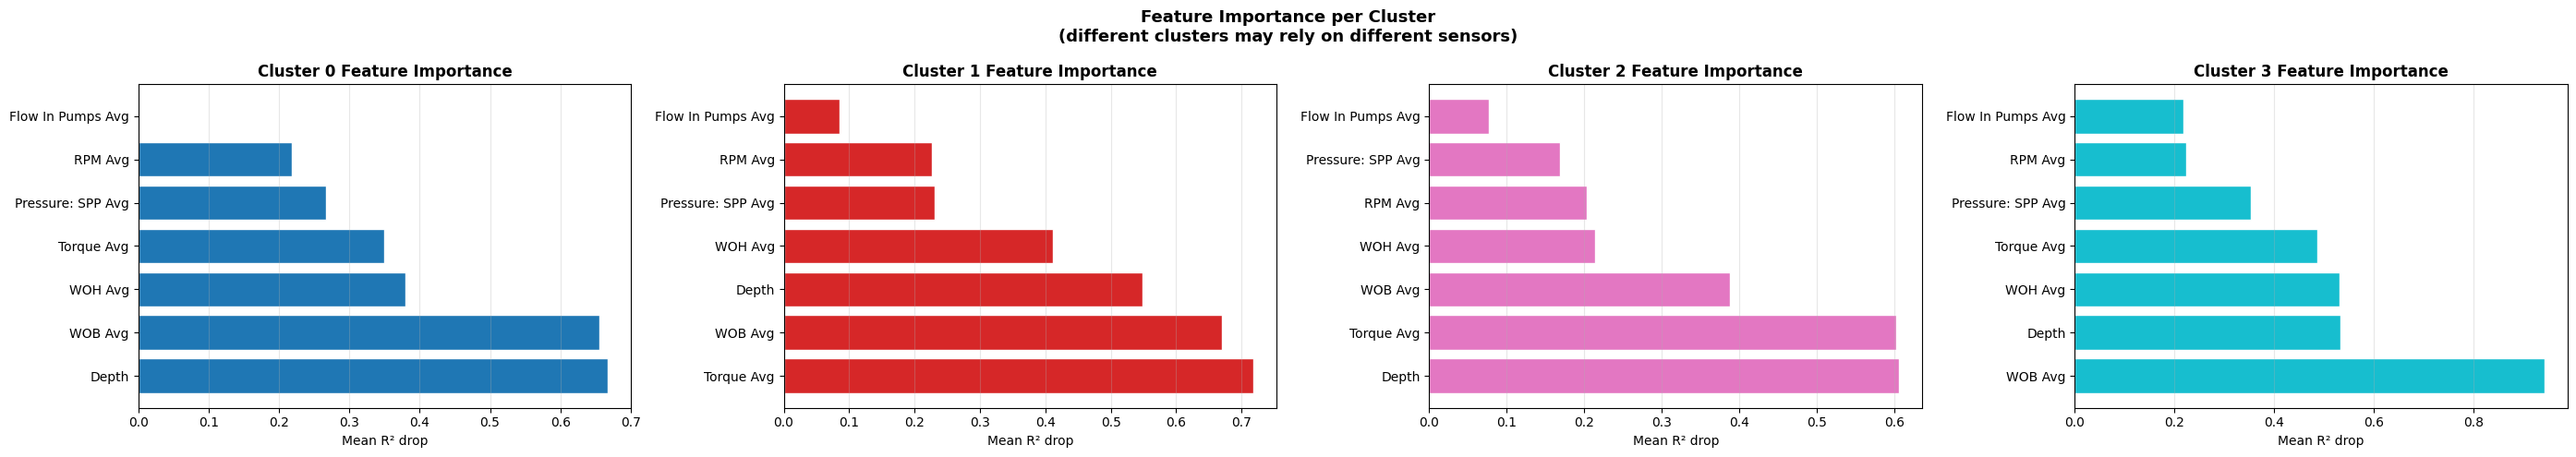

In [12]:
# ─────────────────────────────────────────────
# 11. FEATURE IMPORTANCE PER CLUSTER
# ─────────────────────────────────────────────
def permutation_importance(model, X, y, features, n_repeats=5):
    baseline = r2_score(y, model.predict(X, verbose=0).flatten())
    imp = {}
    for i, f in enumerate(features):
        drops = []
        for _ in range(n_repeats):
            Xp = X.copy(); np.random.shuffle(Xp[:, i])
            drops.append(baseline - r2_score(y, model.predict(Xp, verbose=0).flatten()))
        imp[f] = np.mean(drops)
    return dict(sorted(imp.items(), key=lambda x: x[1], reverse=True))

fig, axes = plt.subplots(1, best_k, figsize=(7 * best_k, 5))
if best_k == 1: axes = [axes]

for cl in range(best_k):
    cl_data = all_df[all_df['cluster'] == cl]
    Xc = cluster_scalers[cl].transform(cl_data[feat_cols].values)
    yc = cl_data[TARGET].values

    # Use a subset for speed
    idx = np.random.choice(len(Xc), min(5000, len(Xc)), replace=False)
    imp = permutation_importance(cluster_models[cl], Xc[idx], yc[idx], feat_cols)

    axes[cl].barh(list(imp.keys()), list(imp.values()),
                  color=cmap_bar(cl), edgecolor='white')
    axes[cl].set_title(f'Cluster {cl} Feature Importance', fontweight='bold')
    axes[cl].set_xlabel('Mean R² drop'); axes[cl].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance per Cluster\n'
             '(different clusters may rely on different sensors)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [13]:
# ─────────────────────────────────────────────
# 12. SAVE ALL CLUSTER MODELS
# ─────────────────────────────────────────────
import joblib, os
SAVE_DIR = 'drive/My Drive/Summer2018/rop_model_v3'
os.makedirs(SAVE_DIR, exist_ok=True)

for cl in range(best_k):
    cluster_models[cl].save(f'{SAVE_DIR}/model_cluster_{cl}.h5')
    joblib.dump(cluster_scalers[cl], f'{SAVE_DIR}/scaler_cluster_{cl}.pkl')

joblib.dump(km_final,          f'{SAVE_DIR}/kmeans.pkl')
joblib.dump(fp_global_scaler,  f'{SAVE_DIR}/fp_scaler.pkl')
joblib.dump(fingerprints,      f'{SAVE_DIR}/fingerprints.pkl')
joblib.dump(feat_cols,         f'{SAVE_DIR}/features.pkl')
joblib.dump(well_to_cluster,   f'{SAVE_DIR}/well_to_cluster.pkl')

print(f'✅ All {best_k} cluster models saved to {SAVE_DIR}')

✅ All 4 cluster models saved to drive/My Drive/Summer2018/rop_model_v3


In [15]:
# ─────────────────────────────────────────────
# 13. SMART INFERENCE FOR A NEW WELL
#
# Given a new well's data (even just a few rows),
# auto-assign it to the right cluster model.
# ─────────────────────────────────────────────
def predict_new_well(well_df, feat_cols, target,
                     km_model, fp_scaler, fingerprints_ref,
                     cluster_models, cluster_scalers):
    """
    Full inference pipeline for a new well.
    1. Compute fingerprint
    2. Assign to nearest cluster
    3. Normalise with that cluster's scaler
    4. Predict with that cluster's model
    """
    # Build fingerprint
    fp = {}
    for f in feat_cols + ([target] if target in well_df.columns else []):
        if f not in well_df.columns: continue
        fp[f'{f}_median'] = well_df[f].median()
        fp[f'{f}_std']    = well_df[f].std()
        fp[f'{f}_p25']    = well_df[f].quantile(0.25)
        fp[f'{f}_p75']    = well_df[f].quantile(0.75)

    fp_vec = np.array([fp.get(c, 0) for c in fingerprints_ref.columns]).reshape(1, -1)
    fp_vec_sc = fp_scaler.transform(fp_vec)
    cl = int(km_model.predict(fp_vec_sc)[0])
    print(f'  → Assigned to Cluster {cl}')

    # Predict
    X = cluster_scalers[cl].transform(well_df[feat_cols].values)
    preds = cluster_models[cl].predict(X, verbose=0).flatten()
    return preds, cl


# ── Example usage ──────────────────────────────
# Use well 7 as a demo new well
demo_well = all_df[all_df['well_id'] == 7].copy()
demo_true = demo_well[TARGET].values

print('Running smart inference on demo well 7...')
demo_pred, assigned_cl = predict_new_well(
    demo_well, feat_cols, TARGET,
    km_final, fp_global_scaler, fingerprints,
    cluster_models, cluster_scalers
)

r2 = r2_score(demo_true, demo_pred)
print(f'  R²   = {r2*100:.1f}%')
print(f'  MAE  = {mean_absolute_error(demo_true, demo_pred):.2f} ft/hr')
print(f'  RMSE = {np.sqrt(mean_squared_error(demo_true, demo_pred)):.2f} ft/hr')

Running smart inference on demo well 7...
  → Assigned to Cluster 0
  R²   = 91.1%
  MAE  = 3.79 ft/hr
  RMSE = 6.04 ft/hr
